# Notebook 02 — Learner Engagement Analysis

**Project:** Programme Health Intelligence: A Learning Analytics Case Study  
**Dataset:** Open University Learning Analytics Dataset (OULAD)  
**Author:** Megha Sinha  
**Date:** June 2026

---

## Objective

This notebook investigates how Virtual Learning Environment (VLE) engagement
behaviour relates to final student outcomes, addressing Business Question 2:

*How does VLE interaction (total clicks, activity type, engagement timing)
correlate with final outcomes? Is there a measurable engagement threshold
below which failure or withdrawal becomes significantly more likely?*

### What We Will Cover
1. Load cleaned data from `data/processed/`
2. Explore overall VLE engagement patterns
3. Analyse engagement levels by final outcome
4. Identify engagement thresholds associated with poor outcomes
5. Examine which activity types are most associated with success
6. Visualise findings for stakeholder communication

---

## 1. Import Libraries

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ── Global Style Settings ──────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.titlepad':      12,
    'axes.labelsize':     11,
    'axes.labelcolor':    '#2C2C2C',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'figure.dpi':         130,
    'savefig.dpi':        150,
    'savefig.bbox':       'tight'
})

sns.set_theme(style='whitegrid', rc={
    'grid.color':     '#E5E5E5',
    'grid.linewidth': 0.7
})

# ── Display Settings ───────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Business Colour Palette ────────────────────────────────────────
outcome_colours = {
    'Pass':        '#2C5F8A',
    'Distinction': '#1A3A5C',
    'Fail':        '#C0392B',
    'Withdrawn':   '#7F8C8D'
}

# Helper — add value labels on bars
def add_bar_labels(ax, fmt='{:.0f}', padding=2, fontsize=10, color='#2C2C2C'):
    for bar in ax.patches:
        val = bar.get_height()
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + padding,
                fmt.format(val),
                ha='center', va='bottom',
                fontsize=fontsize, color=color, fontweight='bold'
            )

print("Global styles and palette loaded successfully")

Global styles and palette loaded successfully


---

## 2. Load Cleaned Data

In [18]:
# Load cleaned files from processed folder
processed_path = '../data/processed/'

student_info = pd.read_csv(processed_path + 'studentInfo_clean.csv')
student_vle  = pd.read_csv(processed_path + 'studentVle_sampled.csv')
vle          = pd.read_csv(processed_path + 'vle_clean.csv')

print("Files loaded successfully\n")
print(f"  student_info:  {student_info.shape[0]:,} rows")
print(f"  student_vle:   {student_vle.shape[0]:,} rows")
print(f"  vle:           {vle.shape[0]:,} rows")

Files loaded successfully

  student_info:  32,593 rows
  student_vle:   1,065,529 rows
  vle:           6,364 rows


---

## 3. VLE Engagement Overview

Before linking engagement to outcomes, we first understand the overall
shape of the engagement data — how many clicks students generate, how
that varies, and whether there are any outliers to be aware of.

In [19]:
# Aggregate total clicks per student per module
student_clicks = (
    student_vle
    .groupby(['id_student', 'code_module', 'code_presentation'])['sum_click']
    .sum()
    .reset_index()
    .rename(columns={'sum_click': 'total_clicks'})
)

print("=== ENGAGEMENT SUMMARY ===\n")
print(f"Students with VLE activity:  {student_clicks['id_student'].nunique():,}")
print(f"\nClicks distribution:")
print(student_clicks['total_clicks'].describe().round(1))

print("\nSample — highest engagement students:")
print(student_clicks.sort_values('total_clicks', ascending=False).head(5))
print("...\nSample — lowest engagement students:")
print(student_clicks.sort_values('total_clicks', ascending=True).head(5))

=== ENGAGEMENT SUMMARY ===

Students with VLE activity:  25,193

Clicks distribution:
count   28078.00
mean      141.10
std       183.70
min         1.00
25%        27.00
50%        76.00
75%       183.00
max      4153.00
Name: total_clicks, dtype: float64

Sample — highest engagement students:
       id_student code_module code_presentation  total_clicks
18084      620337         DDD             2014B          4153
3602       368315         FFF             2013J          2538
418         80868         CCC             2014J          2451
7500       517269         FFF             2013B          2399
17232      611417         CCC             2014J          2052
...
Sample — lowest engagement students:
       id_student code_module code_presentation  total_clicks
7220       510868         BBB             2013J             1
4670       418486         FFF             2014J             1
7997       527505         FFF             2013B             1
25882     1981053         DDD             2

### 3.1 Click Distribution

Understanding the spread of engagement across all students — identifying
the typical range, and flagging outliers that could skew analysis.

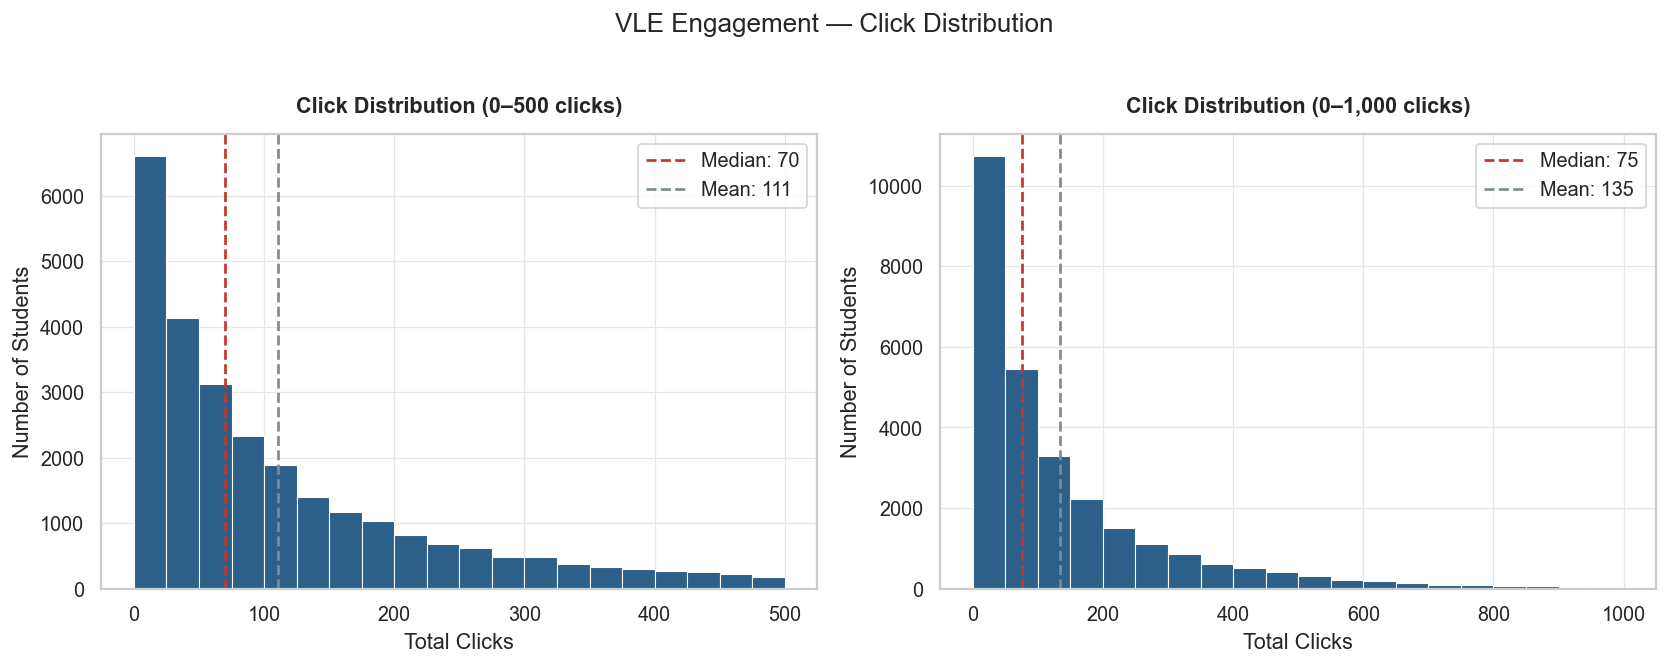

Chart saved to images/


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — capped at 500
capped_500 = student_clicks[student_clicks['total_clicks'] <= 500]
axes[0].hist(capped_500['total_clicks'], bins=range(0, 501, 25),
             color='#2C5F8A', edgecolor='white', linewidth=0.6)
axes[0].axvline(capped_500['total_clicks'].median(), color='#C0392B',
                linestyle='--', linewidth=1.5,
                label=f"Median: {capped_500['total_clicks'].median():.0f}")
axes[0].axvline(capped_500['total_clicks'].mean(), color='#7F8C8D',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {capped_500['total_clicks'].mean():.0f}")
axes[0].set_title('Click Distribution (0–500 clicks)')
axes[0].set_xlabel('Total Clicks')
axes[0].set_ylabel('Number of Students')
axes[0].legend()

# Right — capped at 1000
capped_1000 = student_clicks[student_clicks['total_clicks'] <= 1000]
axes[1].hist(capped_1000['total_clicks'], bins=range(0, 1001, 50),
             color='#2C5F8A', edgecolor='white', linewidth=0.6)
axes[1].axvline(capped_1000['total_clicks'].median(), color='#C0392B',
                linestyle='--', linewidth=1.5,
                label=f"Median: {capped_1000['total_clicks'].median():.0f}")
axes[1].axvline(capped_1000['total_clicks'].mean(), color='#7F8C8D',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {capped_1000['total_clicks'].mean():.0f}")
axes[1].set_title('Click Distribution (0–1,000 clicks)')
axes[1].set_xlabel('Total Clicks')
axes[1].set_ylabel('Number of Students')
axes[1].legend()

fig.suptitle('VLE Engagement — Click Distribution', y=1.02)
plt.tight_layout()
plt.savefig('../images/03_click_distribution.png')
plt.show()
print("Chart saved to images/")

---

## 4. Engagement by Final Outcome

Now we link VLE engagement to final outcomes — does higher engagement
correlate with better results? And is there a threshold below which
poor outcomes become significantly more likely?

In [14]:
# Merge student_clicks with student_info to get final outcomes
engagement_outcomes = student_clicks.merge(
    student_info[['id_student', 'code_module',
                  'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='inner'
)

# Summary statistics by outcome
engagement_by_outcome = (
    engagement_outcomes
    .groupby('final_result')['total_clicks']
    .describe()
    .round(1)
)

print("=== ENGAGEMENT BY FINAL OUTCOME ===\n")
print(engagement_by_outcome)

# Median clicks per outcome — cleaner summary
print("\nMedian clicks by outcome:")
median_clicks = (
    engagement_outcomes
    .groupby('final_result')['total_clicks']
    .median()
    .sort_values(ascending=False)
    .round(1)
)
print(median_clicks)

=== ENGAGEMENT BY FINAL OUTCOME ===

                count   mean    std  min   25%    50%    75%     max
final_result                                                        
Distinction   3024.00 266.60 250.20 2.00 89.00 186.00 368.00 1980.00
Fail          6293.00  72.90 118.40 1.00 13.00  36.00  88.00 4153.00
Pass         12347.00 192.60 195.30 1.00 63.00 129.00 258.00 2538.00
Withdrawn     6414.00  49.70  74.80 1.00  8.00  24.00  61.00 1166.00

Median clicks by outcome:
final_result
Distinction   186.00
Pass          129.00
Fail           36.00
Withdrawn      24.00
Name: total_clicks, dtype: float64


---

### 4.1 Engagement by Outcome — Visualisation

Visualising the difference in click distributions across outcome groups
to make the engagement-outcome relationship clear for stakeholders.

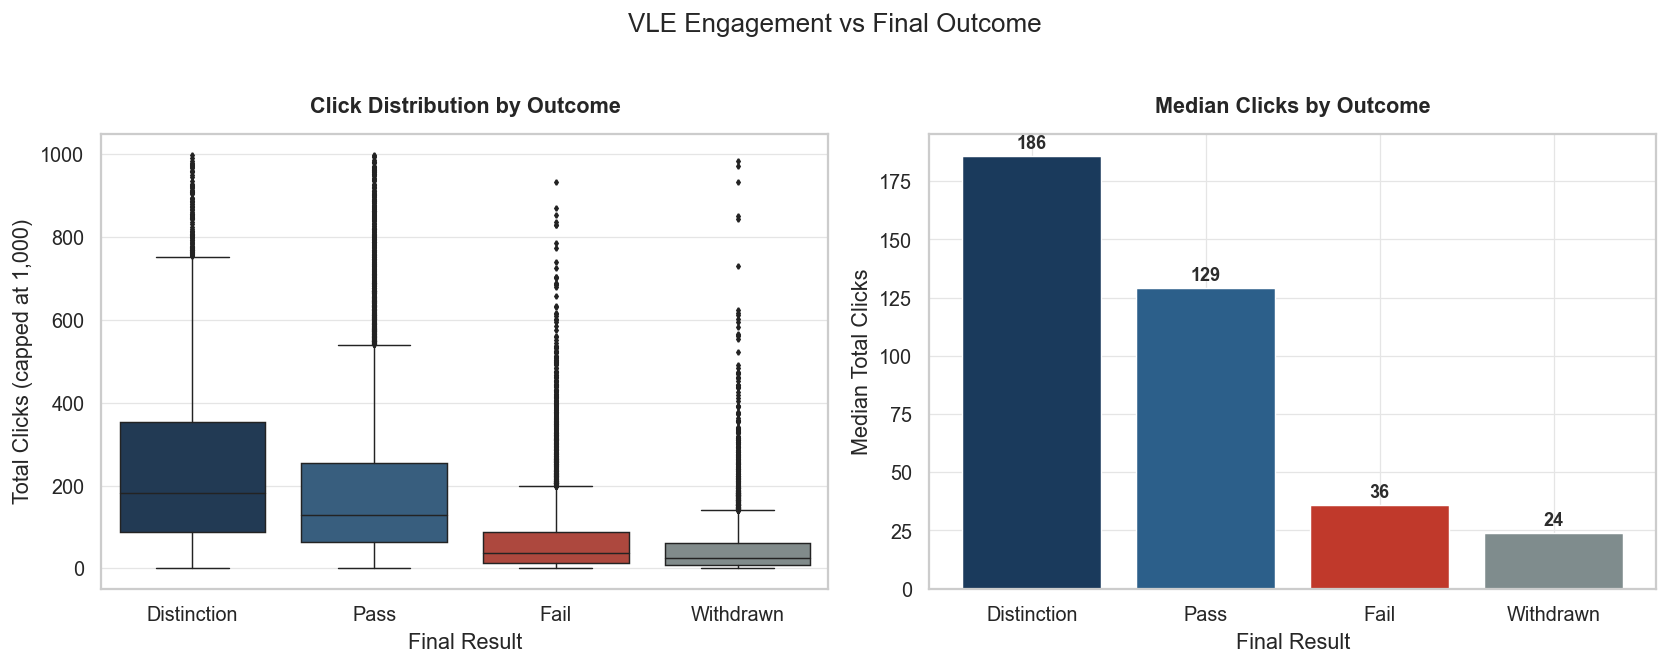

Chart saved to images/


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

outcome_order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
capped_eng = engagement_outcomes[
    engagement_outcomes['total_clicks'] <= 1000].copy()

# Left — box plot
sns.boxplot(
    data=capped_eng,
    x='final_result',
    y='total_clicks',
    order=outcome_order,
    palette=outcome_colours,
    ax=axes[0],
    linewidth=0.8,
    fliersize=2
)
axes[0].set_title('Click Distribution by Outcome')
axes[0].set_xlabel('Final Result')
axes[0].set_ylabel('Total Clicks (capped at 1,000)')

# Right — median bar chart
median_clicks = (
    engagement_outcomes
    .groupby('final_result')['total_clicks']
    .median()
    .reindex(outcome_order)
)
colours_list = [outcome_colours[o] for o in outcome_order]
bars = axes[1].bar(median_clicks.index, median_clicks.values,
                   color=colours_list, edgecolor='white', linewidth=0.8)
axes[1].set_title('Median Clicks by Outcome')
axes[1].set_xlabel('Final Result')
axes[1].set_ylabel('Median Total Clicks')
add_bar_labels(axes[1], padding=1.5)

fig.suptitle('VLE Engagement vs Final Outcome', y=1.02)
plt.tight_layout()
plt.savefig('../images/04_engagement_by_outcome.png')
plt.show()
print("Chart saved to images/")

---

## 5. Engagement Threshold Analysis

The median clicks analysis shows a clear pattern — but where exactly is
the threshold below which poor outcomes become significantly more likely?
We define engagement bands and examine outcome rates within each band.

In [24]:
# Define engagement bands based on click distribution
engagement_outcomes['engagement_band'] = pd.cut(
    engagement_outcomes['total_clicks'],
    bins=[0, 25, 75, 150, 300, float('inf')],
    labels=['Very Low (0-25)', 'Low (26-75)',
            'Medium (76-150)', 'High (151-300)', 'Very High (300+)']
)

# Outcome rates within each engagement band
band_outcomes = (
    engagement_outcomes
    .groupby(['engagement_band', 'final_result'])
    .size()
    .unstack(fill_value=0)
)

# Reorder columns
col_order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
band_outcomes = band_outcomes.reindex(columns=col_order, fill_value=0)

# Add success rate column (Pass + Distinction)
band_outcomes['total'] = band_outcomes.sum(axis=1)
band_outcomes['success_rate'] = (
    (band_outcomes.get('Pass', 0) + band_outcomes.get('Distinction', 0))
    / band_outcomes['total'] * 100
).round(1)

# Add withdrawal rate column
band_outcomes['withdrawal_rate'] = (
    band_outcomes.get('Withdrawn', 0)
    / band_outcomes['total'] * 100
).round(1)

print("=== OUTCOME RATES BY ENGAGEMENT BAND ===\n")
print(band_outcomes)

print("\nKey insight — Success rate by engagement band:")
print(band_outcomes[['total', 'success_rate', 'withdrawal_rate']])

=== OUTCOME RATES BY ENGAGEMENT BAND ===

final_result      Distinction  Pass  Fail  Withdrawn  total  success_rate  \
engagement_band                                                             
Very Low (0-25)            96   840  2585       3287   6808         13.70   
Low (26-75)               526  2893  1882       1857   7158         47.80   
Medium (76-150)           668  3099   991        807   5565         67.70   
High (151-300)            754  3068   582        373   4777         80.00   
Very High (300+)          980  2447   253         90   3770         90.90   

final_result      withdrawal_rate  
engagement_band                    
Very Low (0-25)             48.30  
Low (26-75)                 25.90  
Medium (76-150)             14.50  
High (151-300)               7.80  
Very High (300+)             2.40  

Key insight — Success rate by engagement band:
final_result      total  success_rate  withdrawal_rate
engagement_band                                       
Very Low

---

### 5.1 Engagement Band Outcomes — Visualisation

Visualising how success and withdrawal rates change across engagement
bands to communicate the intervention threshold clearly to stakeholders.

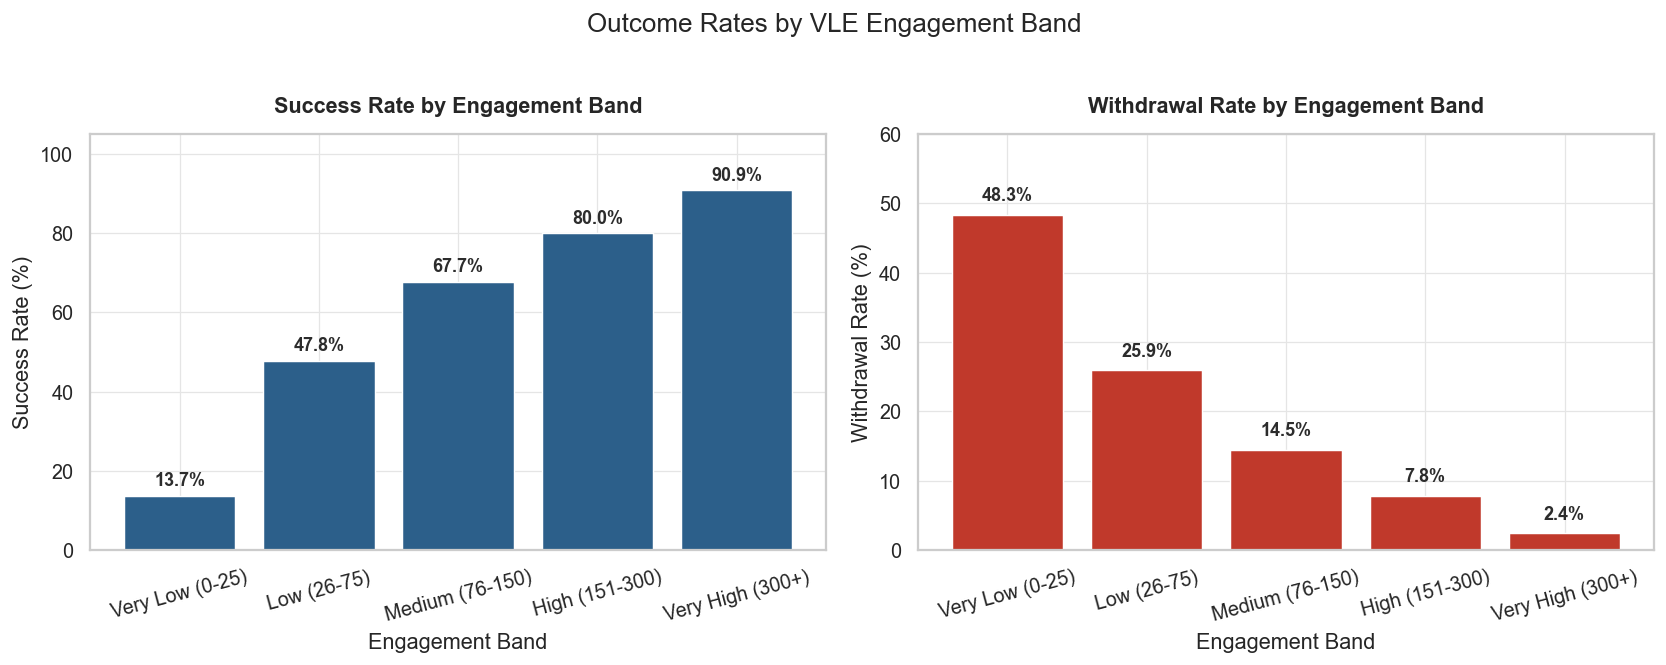

Chart saved to images/


In [25]:
band_summary = band_outcomes[['total', 'success_rate', 'withdrawal_rate']].copy()
band_labels = band_summary.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — success rate by engagement band
bars1 = axes[0].bar(band_labels, band_summary['success_rate'],
                    color='#2C5F8A', edgecolor='white', linewidth=0.8)
axes[0].set_title('Success Rate by Engagement Band')
axes[0].set_xlabel('Engagement Band')
axes[0].set_ylabel('Success Rate (%)')
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis='x', rotation=15)
add_bar_labels(axes[0], fmt='{:.1f}%', padding=1.5)

# Right — withdrawal rate by engagement band
bars2 = axes[1].bar(band_labels, band_summary['withdrawal_rate'],
                    color='#C0392B', edgecolor='white', linewidth=0.8)
axes[1].set_title('Withdrawal Rate by Engagement Band')
axes[1].set_xlabel('Engagement Band')
axes[1].set_ylabel('Withdrawal Rate (%)')
axes[1].set_ylim(0, 60)
axes[1].tick_params(axis='x', rotation=15)
add_bar_labels(axes[1], fmt='{:.1f}%', padding=1.5)

fig.suptitle('Outcome Rates by VLE Engagement Band', y=1.02)
plt.tight_layout()
plt.savefig('../images/05_engagement_bands.png')
plt.show()
print("Chart saved to images/")

---

## 6. Activity Type Analysis

Not all VLE activity is equal. Here we examine which types of learning
activities are most associated with successful outcomes — helping
identify not just how much students engage, but how they engage.

In [27]:
# Merge student_vle with vle to get activity types
vle_with_type = student_vle.merge(
    vle[['id_site', 'activity_type']],
    on='id_site',
    how='left'
)

# Merge with outcomes
vle_outcomes = vle_with_type.merge(
    student_info[['id_student', 'code_module',
                  'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='inner'
)

# Total clicks by activity type and outcome
activity_outcomes = (
    vle_outcomes
    .groupby(['activity_type', 'final_result'])['sum_click']
    .sum()
    .unstack(fill_value=0)
)
activity_outcomes = activity_outcomes.reindex(
    columns=['Distinction', 'Pass', 'Fail', 'Withdrawn'], fill_value=0)

# Calculate % of clicks from each activity type per outcome
activity_pct = activity_outcomes.div(activity_outcomes.sum(axis=0), axis=1) * 100

print("=== CLICKS BY ACTIVITY TYPE AND OUTCOME ===\n")
print(activity_outcomes)

print("\nSample — top 5 activity types by total clicks:")
activity_outcomes['total'] = activity_outcomes.sum(axis=1)
print(activity_outcomes.sort_values('total', ascending=False).head())

=== CLICKS BY ACTIVITY TYPE AND OUTCOME ===

final_result    Distinction    Pass    Fail  Withdrawn
activity_type                                         
dataplus               1507    2883     139         23
dualpane                388    1332     200        136
externalquiz            784    4004    1019        696
folder                   58     405      42          6
forumng              189334  461067   79898      65822
glossary               1718    5697     869        667
homepage             141296  405862   83079      63055
htmlactivity            115     437     115        231
oucollaborate          1763    7027    1243       1009
oucontent            217824  711661  122797      78030
ouelluminate            458    2436     718        370
ouwiki                21556   56613    8060       5262
page                   1204    3384    1064        843
questionnaire          1608    3894     536        345
quiz                 139338  419498   82954      48821
repeatactivity      

---

### 6.1 Activity Type — Visualisation

Comparing click volume by activity type across outcome groups to identify
which activities most strongly differentiate successful from unsuccessful learners.

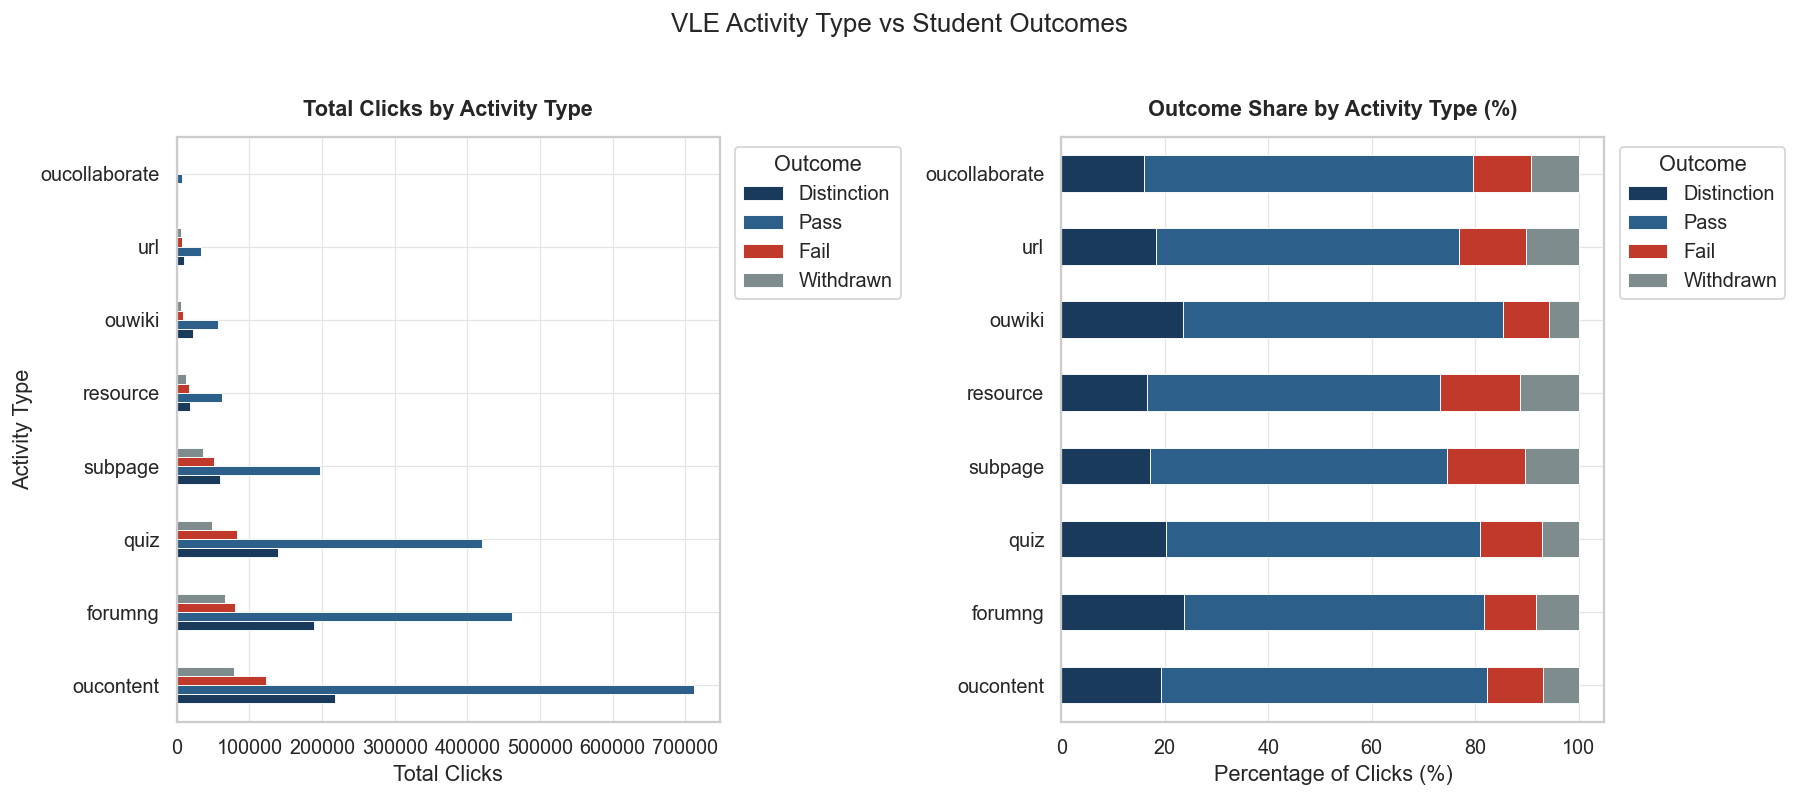

Chart saved to images/


In [29]:
# Top 8 activity types by total clicks — exclude homepage as navigation noise
top_activities = (
    activity_outcomes
    .drop('total', axis=1)
    .sum(axis=1)
    .sort_values(ascending=False)
)
top_activities = top_activities[top_activities.index != 'homepage'].head(8).index.tolist()

plot_data = activity_outcomes.loc[top_activities, 
            ['Distinction', 'Pass', 'Fail', 'Withdrawn']]

# Normalise to percentage of each activity's total clicks
plot_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — absolute clicks by activity type
plot_data.plot(
    kind='barh',
    color=[outcome_colours[c] for c in plot_data.columns],
    ax=axes[0],
    edgecolor='white',
    linewidth=0.5
)
axes[0].set_title('Total Clicks by Activity Type')
axes[0].set_xlabel('Total Clicks')
axes[0].set_ylabel('Activity Type')
axes[0].legend(title='Outcome', bbox_to_anchor=(1.01, 1), loc='upper left')

# Right — percentage breakdown by activity type
plot_pct.plot(
    kind='barh',
    stacked=True,
    color=[outcome_colours[c] for c in plot_pct.columns],
    ax=axes[1],
    edgecolor='white',
    linewidth=0.5
)
axes[1].set_title('Outcome Share by Activity Type (%)')
axes[1].set_xlabel('Percentage of Clicks (%)')
axes[1].set_ylabel('')
axes[1].legend(title='Outcome', bbox_to_anchor=(1.01, 1), loc='upper left')

fig.suptitle('VLE Activity Type vs Student Outcomes', y=1.02)
plt.tight_layout()
plt.savefig('../images/06_activity_type_outcomes.png')
plt.show()
print("Chart saved to images/")

---

## 7. Engagement Over Time

So far we have looked at total engagement. Now we examine *when* students
engage — does engagement drop off at a particular point in the module?
Are there periods of consistently low engagement that precede withdrawal?

In [38]:
# Merge student_vle with outcomes
vle_time = student_vle.merge(
    student_info[['id_student', 'code_module',
                  'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='inner'
)

# Filter to module date range (day 0 onwards — exclude pre-module activity)
vle_time = vle_time[vle_time['date'] >= 0]

# Weekly engagement — group by week
vle_time['week'] = (vle_time['date'] // 7).astype(int)

print("=== VLE TIME DATA — SUMMARY ===\n")
print(f"Total records:       {len(vle_time):,}")
print(f"Unique students:     {vle_time['id_student'].nunique():,}")
print(f"Date range (days):   {vle_time['date'].min()} to {vle_time['date'].max()}")
print(f"Week range:          Week {vle_time['week'].min()} to Week {vle_time['week'].max()}")

=== VLE TIME DATA — SUMMARY ===

Total records:       997,273
Unique students:     24,663
Date range (days):   0 to 269
Week range:          Week 0 to Week 38


---

### 7.1 Note on Temporal Engagement Analysis

Initial exploration of weekly engagement patterns and pre-withdrawal
click behaviour was conducted but did not yield statistically
distinguishable signals at the aggregate level.

Two key reasons:

1. **Mixed student states** — weekly averages pool students at different
   stages of engagement, flattening individual drop-off patterns
2. **Variable withdrawal timing** — withdrawn students left at different
   points across the module, making aggregate pre-withdrawal averages
   uninformative

**Recommendation for future analysis:** Individual-level longitudinal
tracking — flagging the week each student's clicks drop to zero and
measuring distance to withdrawal — would yield more precise intervention
timing signals. This is noted as a recommended next step in the findings
report.

The temporal dimension of withdrawal is explored further in
**Notebook 03 — Dropout Timing**, using registration and unregistration
dates which provide a cleaner signal.

---

## 8. Notebook Summary

### Key Findings

| Finding | Detail |
|---|---|
| Non-engaged students | ~7,400 students have no VLE activity recorded |
| Engagement-outcome correlation | Clear population-level relationship — median clicks rise from 24 (Withdrawn) to 186 (Distinction) |
| Critical threshold | Students below 75 clicks have <50% success rate and >25% withdrawal rate |
| Very Low engagement band | 6,808 students with 0–25 clicks — 48.3% withdrawal rate, 13.7% success rate |
| Very High engagement band | 3,770 students with 300+ clicks — 90.9% success rate, 2.4% withdrawal rate |
| Activity type | Forum participation differentiates outcomes most strongly (2.4x more clicks for Distinction vs Fail) |
| Clicks as signal | Population-level signal is strong but probabilistic — not deterministic for individuals |
| Temporal analysis | Aggregate weekly patterns inconclusive — individual longitudinal tracking recommended |

### Operational Recommendations

1. **Flag students below 75 clicks** for proactive outreach — success rate drops below 50% at this threshold
2. **Prioritise students below 25 clicks** as critical intervention cases — 48.3% withdrawal rate
3. **Encourage forum participation** — strongest activity-level differentiator between Distinction and Fail students
4. **Avoid relying on week-by-week monitoring alone** — total engagement volume is a more reliable signal than weekly averages

### Files Produced

| File | Location |
|---|---|
| 03_click_distribution.png | images/ |
| 04_engagement_by_outcome.png | images/ |
| 05_engagement_bands.png | images/ |
| 06_activity_type_outcomes.png | images/ |

### Next Steps
**Notebook 03 — Dropout Timing:** When do students withdraw — and is
there a critical intervention window based on registration data?